## Diabetes Readmission Prediction

#### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

#### Load Dataset

In [131]:
#Read the dataset
US_diab_readmission = pd.read_csv("diabetic_data.csv")

#Load the first 5 rows of the dataset
US_diab_readmission.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [132]:
#Load the last 5 rows of the dataset
US_diab_readmission.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


#### Data Cleaning

In [133]:
US_diab_readmission.shape

(101766, 50)

In [134]:
US_diab_readmission.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [135]:
US_diab_readmission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [136]:
#After careful examination, the dataset presents empty NAN values as "?" character
Character_values = (US_diab_readmission == "?").sum().sort_values(ascending=False)

print(Character_values/len(US_diab_readmission)*100)

weight                      96.858479
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
admission_type_id            0.000000
patient_nbr                  0.000000
encounter_id                 0.000000
time_in_hospital             0.000000
admission_source_id          0.000000
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
number_inpatient             0.000000
number_emergency             0.000000
number_outpatient            0.000000
number_diagnoses             0.000000
max_glu_serum                0.000000
A1Cresult                    0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [137]:
#"race", "weight", "diag_3", "payer_code", "medical_specialty", "diag_2", "diag_1"
#Has "?" characters

#The top 3 features has high null values, filling them in will hold no value
US_diab_readmission = US_diab_readmission.drop(columns=["weight", "medical_specialty", "payer_code"])
US_diab_readmission.shape

(101766, 47)

In [138]:
US_diab_readmission.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
encounter_id                    0
gender                          0
age                             0
patient_nbr                     0
race                            0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
admission_type_id               0
discharge_disposition_id        0
number_inpatient                0
number_emergency                0
diag_1                          0
diag_2                          0
number_diagnoses                0
diag_3                          0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide   

In [139]:
#Features: "max_glu_serum" and "A1Cresult" hold high null values
#Therefore, they will provide no value
US_diab_readmission = US_diab_readmission.drop(columns=["max_glu_serum", "A1Cresult"])
US_diab_readmission.shape

(101766, 45)

#### Data Preprocessing

In [140]:
#Feature "race" has 2.23% "?" values
#To further inspection of this feature, understanding the value count will help to detemine the best option to process the "?" values
US_diab_readmission["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [141]:
#To process the "?" value, replacing it with "Other" value is the best way to remove the character
US_diab_readmission["race"] = US_diab_readmission["race"].replace("?", "Other")
US_diab_readmission["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Other               3779
Hispanic            2037
Asian                641
Name: count, dtype: int64

In [142]:
#For features: "diag_3", "diag_2", "diag_1"
#Since each hold insignificant amounts of "?" values
#1.40%, 0.35%, and 0.02% repectively

#The best way to process them would be using mode
#Before doing that, the "?" value needs to be replaced with np.nan

US_diab_readmission = US_diab_readmission.replace("?", np.nan)

for column in ["diag_3", "diag_2", "diag_1"]:
    US_diab_readmission[column].fillna(US_diab_readmission[column].mode()[0], inplace=True)

C:\Users\Johnson\AppData\Local\Temp\ipykernel_8856\2425110682.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  US_diab_readmission[column].fillna(US_diab_readmission[column].mode()[0], inplace=True)


In [143]:
US_diab_readmission.isna().sum().sort_values(ascending=False)

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide

In [144]:
#Now the dataset is clean and doesnt have any null values
US_diab_readmission.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis

In [145]:
US_diab_readmission.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [146]:
#Features: "encounter_id" and "patient_nbr" are unique indentifiers that holds no meaningful values

US_diab_readmission = US_diab_readmission.drop(columns=["encounter_id", "patient_nbr"])
US_diab_readmission.shape

(101766, 43)

In [147]:
US_diab_readmission.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


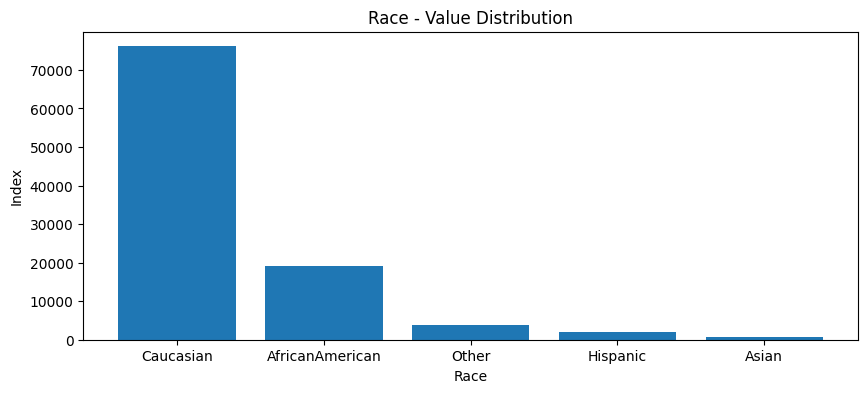

In [148]:
#Data visualisation for feature: race

feat_race = US_diab_readmission["race"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_race.index, feat_race.values)
plt.xlabel("Race")
plt.ylabel("Index")
plt.title("Race - Value Distribution")
plt.show()

#Caucasian value count is the highest
#The plot suggests that there is data imbalance

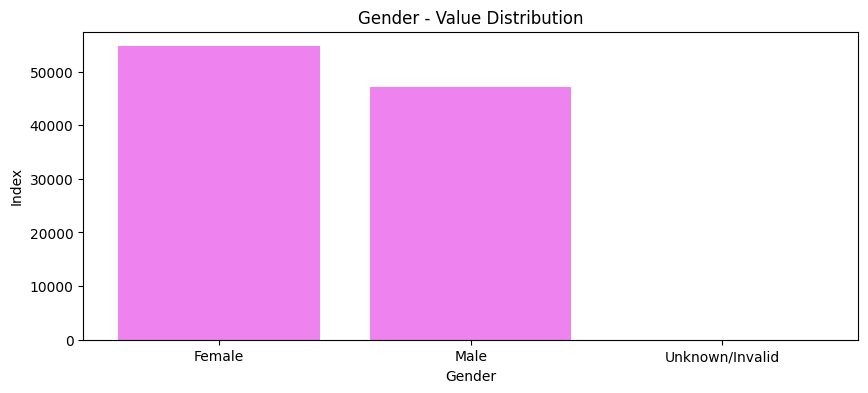

In [149]:
#Data visualisation for feature: gender

feat_gender = US_diab_readmission["gender"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_gender.index, feat_gender.values, color="violet")
plt.xlabel("Gender")
plt.ylabel("Index")
plt.title("Gender - Value Distribution")
plt.show()

#Female has the highest value count
#Unknown/Invalid values are very insignificant, therefore, they can be dropped

In [150]:
print(US_diab_readmission[US_diab_readmission["gender"] == "Unknown/Invalid"].index)

Index([30506, 75551, 82573], dtype='int64')


In [151]:
US_diab_readmission = US_diab_readmission.drop(index=[30506, 75551, 82573])

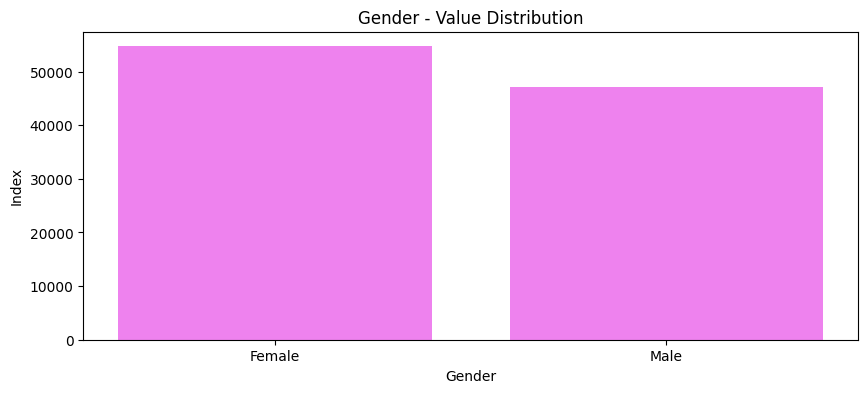

In [152]:
feat_gender = US_diab_readmission["gender"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_gender.index, feat_gender.values, color="violet")
plt.xlabel("Gender")
plt.ylabel("Index")
plt.title("Gender - Value Distribution")
plt.show()

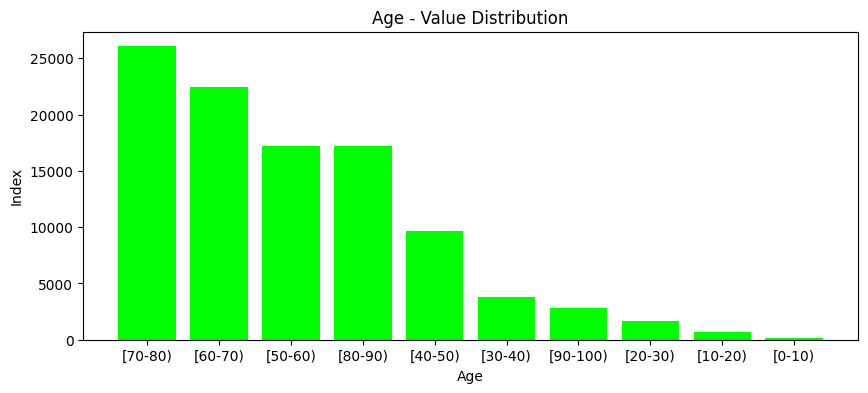

In [153]:
#Data visualisation for feature: age

feat_age = US_diab_readmission["age"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_age.index, feat_age.values, color="lime")
plt.xlabel("Age")
plt.ylabel("Index")
plt.title("Age - Value Distribution")
plt.show()

#Interval 70-80 suggest an older demographic due to its value count
#The interval data needs to formatted in numerical data format for simple data processing

In [154]:
US_diab_readmission["age"] = US_diab_readmission["age"].replace({
    "[70-80)": 75,
    "[60-70)": 65,
    "[50-60)": 55,
    "[80-90)": 85,
    "[40-50)": 45,
    "[30-40)": 35,
    "[90-100)": 95,
    "[20-30)": 25,
    "[10-20)": 15,
    "[0-10)": 5
})

C:\Users\Johnson\AppData\Local\Temp\ipykernel_8856\4096809829.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  US_diab_readmission["age"] = US_diab_readmission["age"].replace({


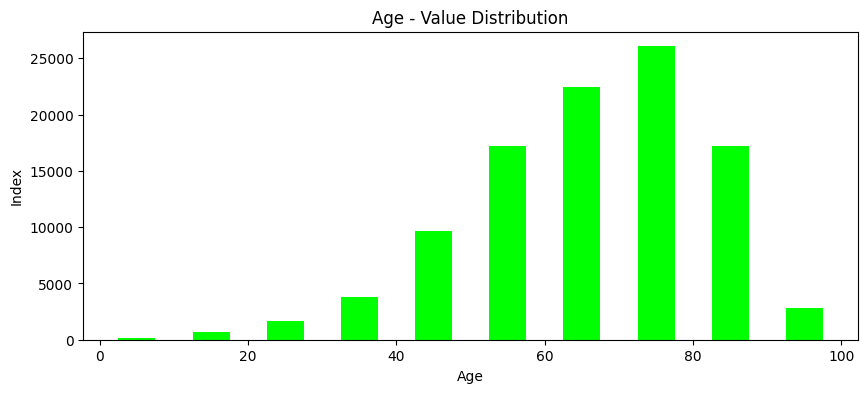

In [155]:
feat_age = US_diab_readmission["age"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_age.index, feat_age.values, color="lime", width=5)
plt.xlabel("Age")
plt.ylabel("Index")
plt.title("Age - Value Distribution")
plt.show()

In [156]:
US_diab_readmission.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,5,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,15,1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,35,1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,45,1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


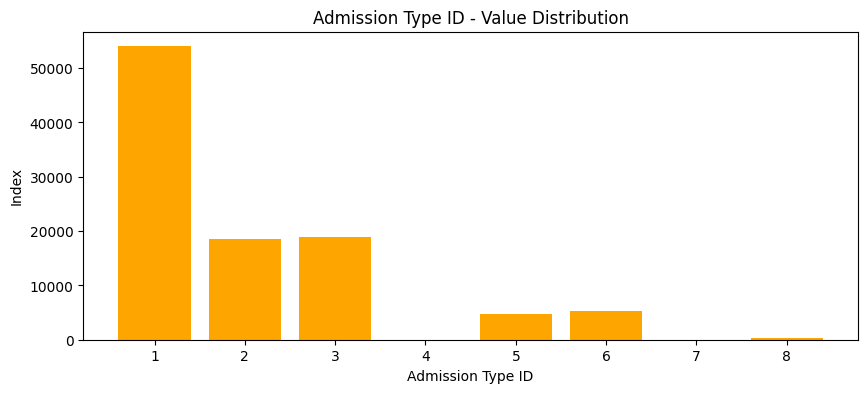

In [157]:
#Data visualisation for feature: admission_type_id

feat_admis_type_id = US_diab_readmission["admission_type_id"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_admis_type_id.index, feat_admis_type_id.values, color="orange")
plt.xlabel("Admission Type ID")
plt.ylabel("Index")
plt.title("Admission Type ID - Value Distribution")
plt.show()

#Again there is imbalance in this data.
#Type ID has the highest value count

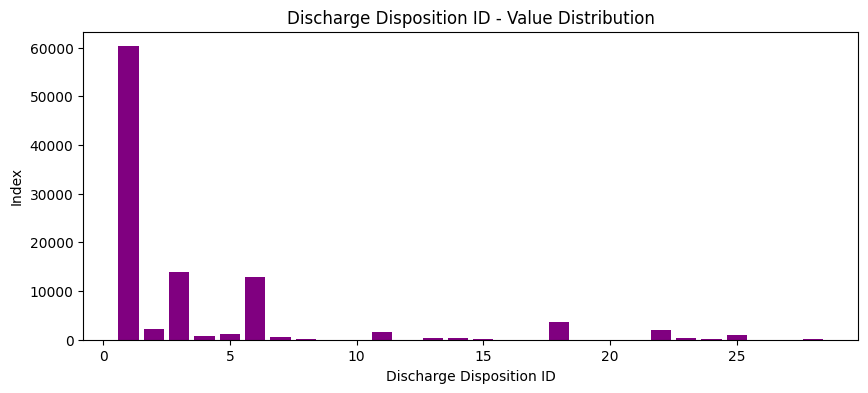

In [158]:
#Data visualisation for feature: discharge_disposition_id

feat_disc_disp_id = US_diab_readmission["discharge_disposition_id"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_disc_disp_id.index, feat_disc_disp_id.values, color="purple")
plt.xlabel("Discharge Disposition ID")
plt.ylabel("Index")
plt.title("Discharge Disposition ID - Value Distribution")
plt.show()

#There is data imbalance, as well as many distinct values

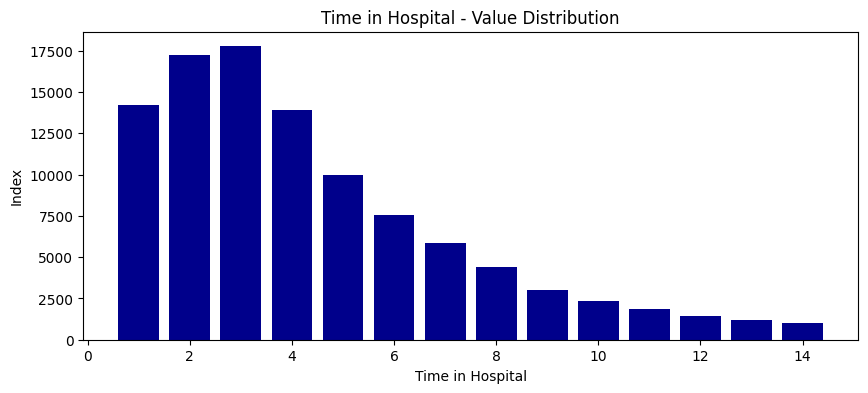

In [159]:
#Data visualisation for feature: time_in_hospital

feat_time_hosp = US_diab_readmission["time_in_hospital"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_time_hosp.index, feat_time_hosp.values, color="darkblue")
plt.xlabel("Time in Hospital")
plt.ylabel("Index")
plt.title("Time in Hospital - Value Distribution")
plt.show()

#Suggest that most patients stayed between 1-4 and the highest being 3 days 

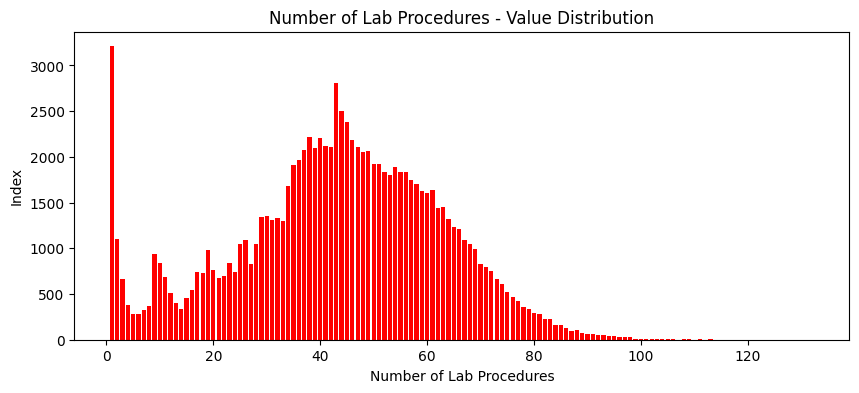

In [160]:
#Data visualisation for feature: num_lab_procedures

feat_lab_proced = US_diab_readmission["num_lab_procedures"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_lab_proced.index, feat_lab_proced.values, color="red")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Index")
plt.title("Number of Lab Procedures - Value Distribution")
plt.show()

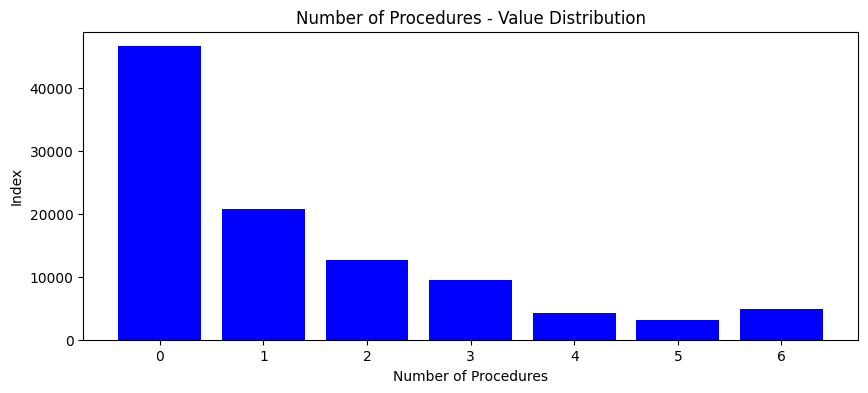

In [161]:
#Data visualisation for feature: num_procedures

feat_num_proced = US_diab_readmission["num_procedures"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_num_proced.index, feat_num_proced.values, color="blue")
plt.xlabel("Number of Procedures")
plt.ylabel("Index")
plt.title("Number of Procedures - Value Distribution")
plt.show()

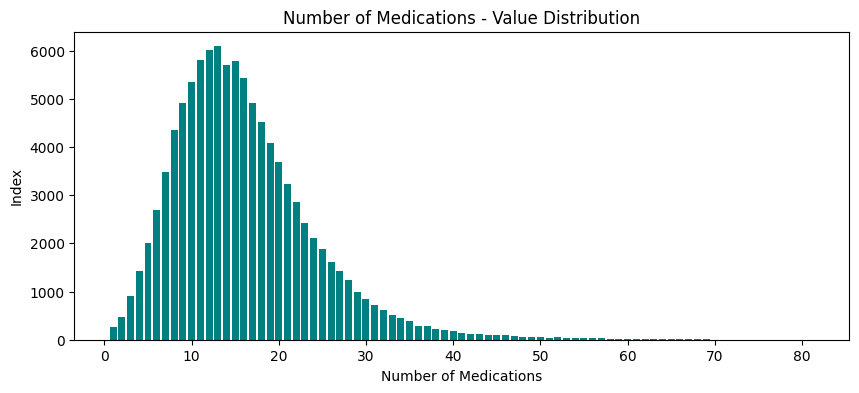

In [162]:
#Data visualisation for feature: num_medications

feat_num_med = US_diab_readmission["num_medications"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_num_med.index, feat_num_med.values, color="teal")
plt.xlabel("Number of Medications")
plt.ylabel("Index")
plt.title("Number of Medications - Value Distribution")
plt.show()

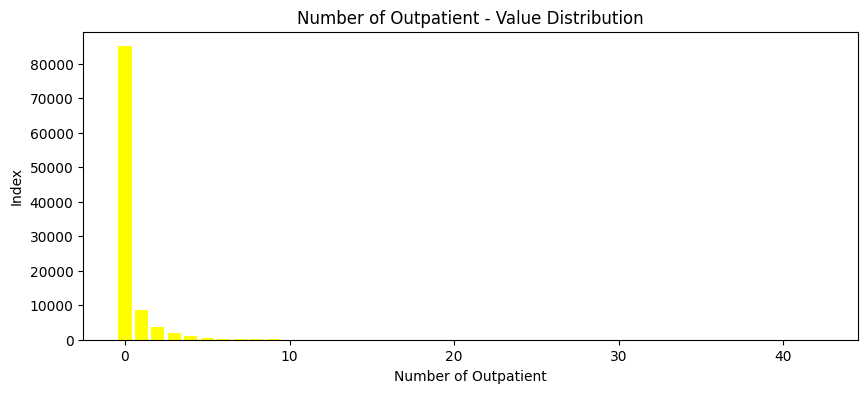

In [163]:
#Data visualisation for feature: number_outpatient

feat_num_outpatient = US_diab_readmission["number_outpatient"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_num_outpatient.index, feat_num_outpatient.values, color="yellow")
plt.xlabel("Number of Outpatient")
plt.ylabel("Index")
plt.title("Number of Outpatient - Value Distribution")
plt.show()

#Lots of distinct values and high imbalance

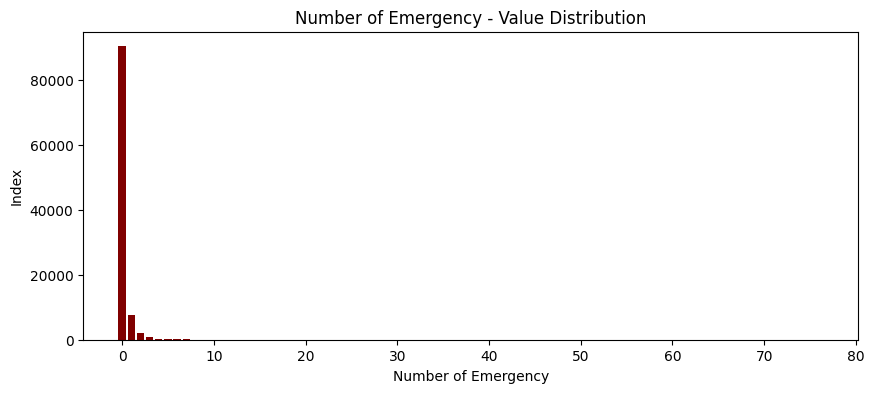

In [164]:
#Data visualisation for feature: number_emergency

feat_num_emergency = US_diab_readmission["number_emergency"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_num_emergency.index, feat_num_emergency.values, color="maroon")
plt.xlabel("Number of Emergency")
plt.ylabel("Index")
plt.title("Number of Emergency - Value Distribution")
plt.show()

#Lots of distinct values and high imbalance

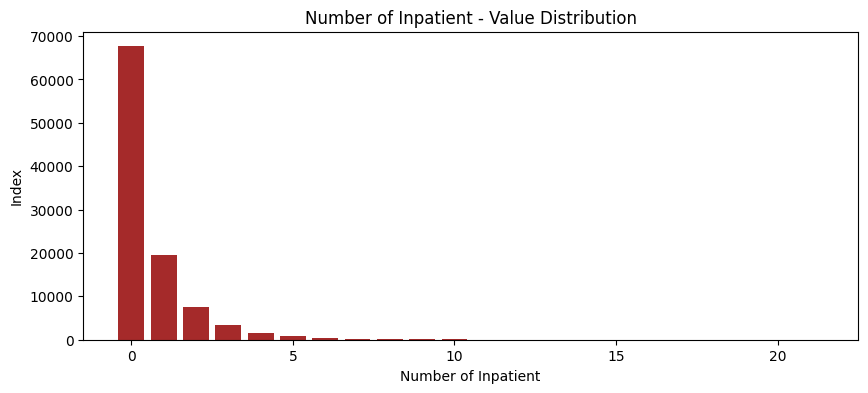

In [165]:
#Data visualisation for feature: number_inpatient

feat_num_inpatient = US_diab_readmission["number_inpatient"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_num_inpatient.index, feat_num_inpatient.values, color="brown")
plt.xlabel("Number of Inpatient")
plt.ylabel("Index")
plt.title("Number of Inpatient - Value Distribution")
plt.show()

#The plot suggests high data imbalance

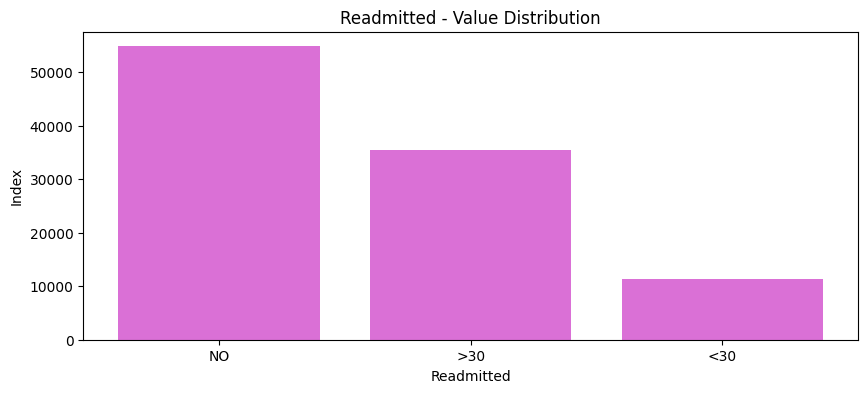

In [166]:
#Data visualisation for feature: number_inpatient

feat_readmitted = US_diab_readmission["readmitted"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_readmitted.index, feat_readmitted.values, color="orchid")
plt.xlabel("Readmitted")
plt.ylabel("Index")
plt.title("Readmitted - Value Distribution")
plt.show()

#This features values are in categorical format
#Changing them to binary format will be better for data processing

In [167]:
US_diab_readmission["readmitted"] = US_diab_readmission["readmitted"].replace({
    "NO": 0,
    ">30": 1,
    "<30": 1,
})

C:\Users\Johnson\AppData\Local\Temp\ipykernel_8856\1107303650.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  US_diab_readmission["readmitted"] = US_diab_readmission["readmitted"].replace({


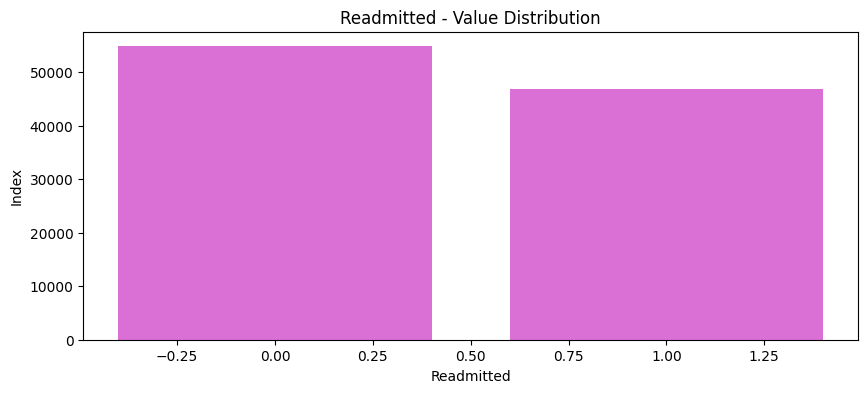

In [168]:
feat_readmitted = US_diab_readmission["readmitted"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(feat_readmitted.index, feat_readmitted.values, color="orchid")
plt.xlabel("Readmitted")
plt.ylabel("Index")
plt.title("Readmitted - Value Distribution")
plt.show()

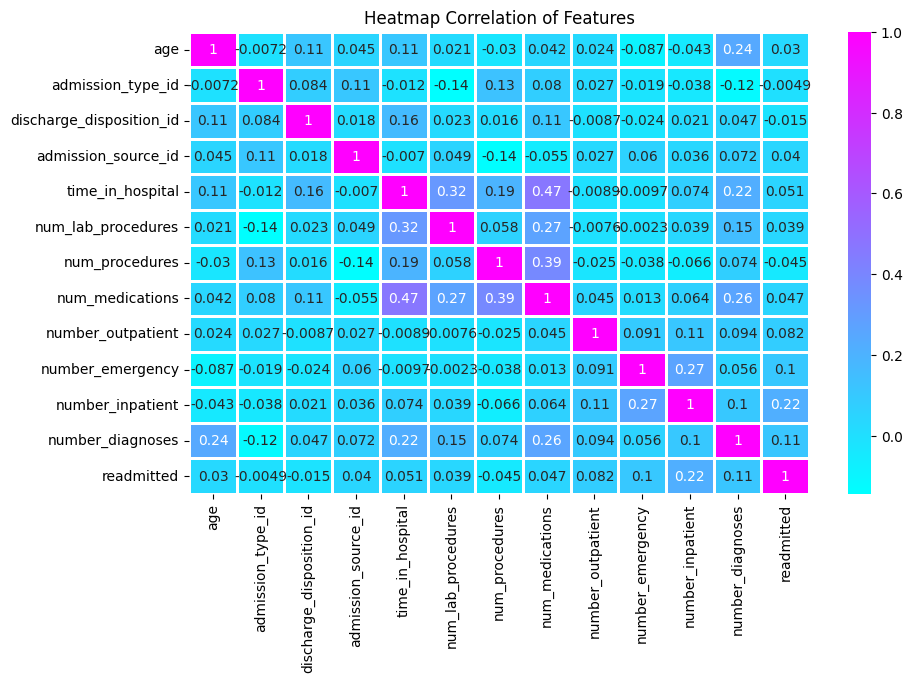

In [169]:
#Finally, A heatmap to understand the features correlation

plt.figure(figsize=(10,6))
sns.heatmap(US_diab_readmission.corr(numeric_only=True), annot=True, linewidths=1, cmap="cool")
plt.title("Heatmap Correlation of Features")
plt.show()

#High correlation between num_medication + time_in_hospital and num_medication + num_procedures

#### Data Categorisation

In [170]:
#To categorise the dataset, understanding features Data type will be important

US_diab_readmission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101763 non-null  object
 1   gender                    101763 non-null  object
 2   age                       101763 non-null  int64 
 3   admission_type_id         101763 non-null  int64 
 4   discharge_disposition_id  101763 non-null  int64 
 5   admission_source_id       101763 non-null  int64 
 6   time_in_hospital          101763 non-null  int64 
 7   num_lab_procedures        101763 non-null  int64 
 8   num_procedures            101763 non-null  int64 
 9   num_medications           101763 non-null  int64 
 10  number_outpatient         101763 non-null  int64 
 11  number_emergency          101763 non-null  int64 
 12  number_inpatient          101763 non-null  int64 
 13  diag_1                    101763 non-null  object
 14  diag_2   

In [171]:
#From the Data types, "object" needs to be categorised into numerical ones

category_feat = US_diab_readmission.select_dtypes(include="object").columns

print(category_feat)

Index(['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')


In [172]:
#In order to perfom data categorisation, label encoder is needed
# Using label encoder, it will make the object data types into 1's and 0's

feat_label_encode = LabelEncoder()

for columns in category_feat:
    US_diab_readmission[columns] = feat_label_encode.fit_transform(US_diab_readmission[columns])

In [173]:
US_diab_readmission.head()

#Now the "object" data types have been encoded into numerical data type

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,0,5,6,25,1,1,41,0,1,...,0,1,1,0,0,0,0,1,0,0
1,2,0,15,1,1,7,3,59,0,18,...,0,3,1,0,0,0,0,0,1,1
2,0,0,25,1,1,7,2,11,5,13,...,0,1,1,0,0,0,0,1,1,0
3,2,1,35,1,1,7,2,44,1,16,...,0,3,1,0,0,0,0,0,1,0
4,2,1,45,1,1,7,1,51,0,8,...,0,2,1,0,0,0,0,0,1,0


In [174]:
US_diab_readmission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101763 non-null  int64
 1   gender                    101763 non-null  int64
 2   age                       101763 non-null  int64
 3   admission_type_id         101763 non-null  int64
 4   discharge_disposition_id  101763 non-null  int64
 5   admission_source_id       101763 non-null  int64
 6   time_in_hospital          101763 non-null  int64
 7   num_lab_procedures        101763 non-null  int64
 8   num_procedures            101763 non-null  int64
 9   num_medications           101763 non-null  int64
 10  number_outpatient         101763 non-null  int64
 11  number_emergency          101763 non-null  int64
 12  number_inpatient          101763 non-null  int64
 13  diag_1                    101763 non-null  int64
 14  diag_2                   

#### Model Training and Testing

In [175]:
X = US_diab_readmission.drop("readmitted", axis=1)

y = US_diab_readmission["readmitted"]

Data Imbalance

In [176]:
#To deal with the high level of Data imbalance, using SMOTE will help to mitigate that
#SMOTE generates synthetic data to fix the imbalance issue, making the dataset more balanced

Imbalance_fix = SMOTE(sampling_strategy="minority", random_state= 42)

X_smote, y_smote = Imbalance_fix.fit_resample(X, y)

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

In [178]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((87777, 42), (21945, 42), (87777,), (21945,))

#### Logistic Regression

In [179]:
#1st Model
Logistic_reg = LogisticRegression(max_iter=10000, random_state=0)
Logistic_reg.fit(X_smote, y_smote)

y_prediction =  Logistic_reg.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 1 - Logistic Regression: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

Model 1 - Logistic Regression: 62.13%
              precision    recall  f1-score   support

           0       0.61      0.70      0.65     11032
           1       0.64      0.55      0.59     10913

    accuracy                           0.62     21945
   macro avg       0.62      0.62      0.62     21945
weighted avg       0.62      0.62      0.62     21945



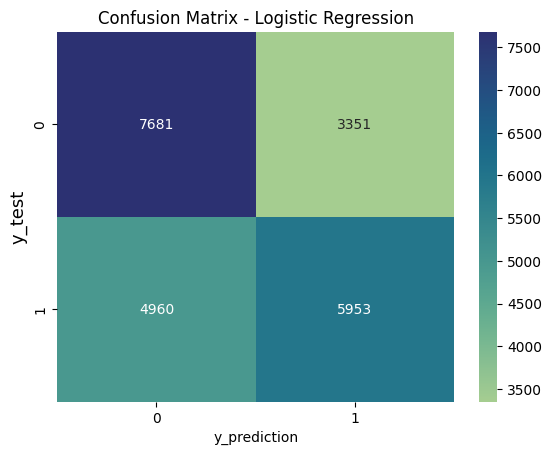

In [180]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="crest")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Logistic Regression AUC-ROC Score:0.66%


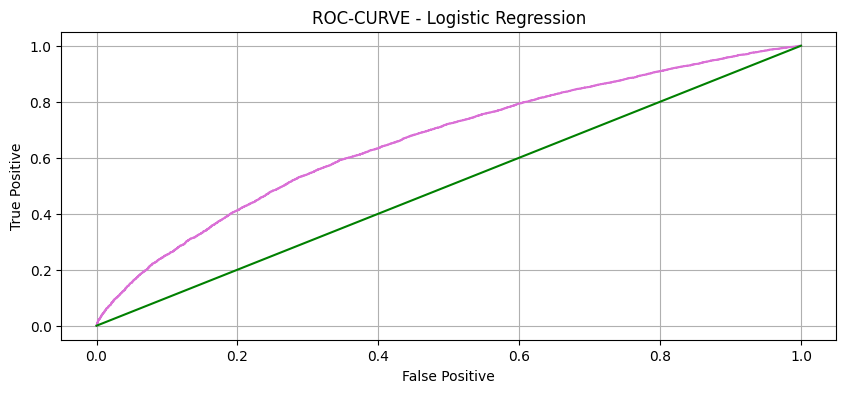

In [181]:
#AUC-ROC Curve & Confusion Matrix - Logistic Regression
y_prediction_probability = Logistic_reg.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"Logistic Regression AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="orchid", label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression")
plt.grid(True)
plt.show()

#### Random Forest

In [182]:
#2nd Model
Random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
Random_forest.fit(X_train, y_train)

y_prediction = Random_forest.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 2 - Random Forest: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

Model 2 - Random Forest: 65.93%
              precision    recall  f1-score   support

           0       0.66      0.68      0.67     11032
           1       0.66      0.64      0.65     10913

    accuracy                           0.66     21945
   macro avg       0.66      0.66      0.66     21945
weighted avg       0.66      0.66      0.66     21945



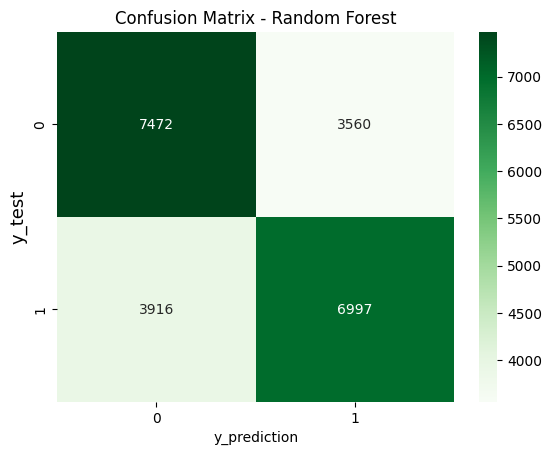

In [183]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Greens")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Random Forest AUC-ROC Score: 0.72%


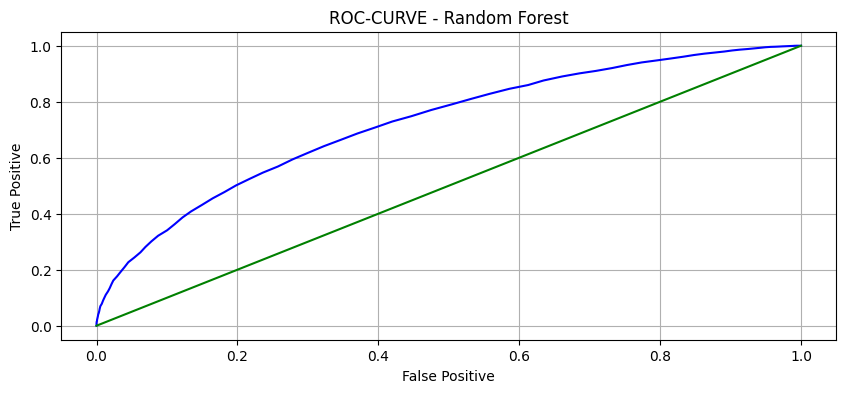

In [184]:
#AUC-ROC Curve & Confusion Matrix - Random Forest
y_prediction_probability = Random_forest.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"Random Forest AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest")
plt.grid(True)
plt.show()

#### XGBoost

In [185]:
#3rd Model
XG_boost = xgb.XGBClassifier()
XG_boost.fit(X_train, y_train)

y_prediction = XG_boost.predict(X_test)

Accuracy = accuracy_score(y_test, y_prediction) *100
print(f"Model 3 - XGBoost: {Accuracy:.2f}%")

Classif_report = classification_report(y_test, y_prediction)
print(Classif_report)

Model 3 - XGBoost: 66.63%
              precision    recall  f1-score   support

           0       0.66      0.68      0.67     11032
           1       0.67      0.65      0.66     10913

    accuracy                           0.67     21945
   macro avg       0.67      0.67      0.67     21945
weighted avg       0.67      0.67      0.67     21945



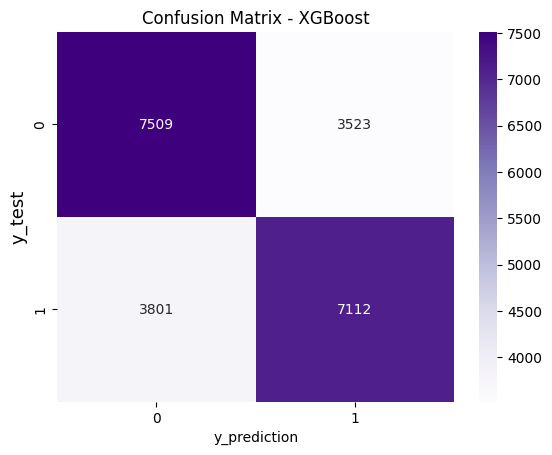

In [186]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Purples")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost")
plt.show()

XGBoost AUC-ROC Score: 0.73%


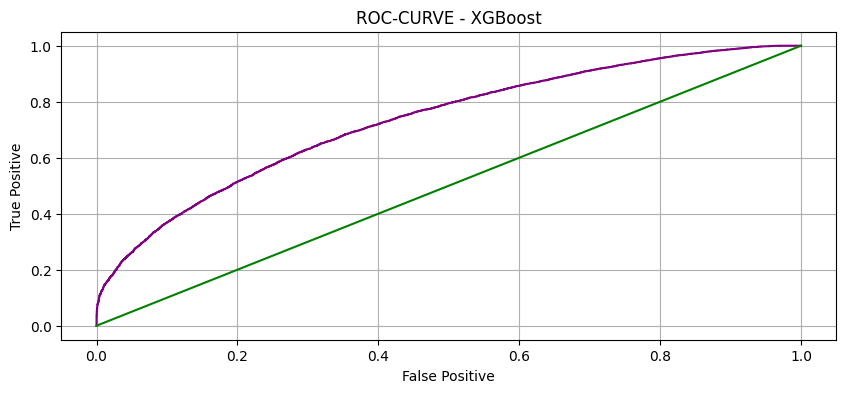

In [187]:
#AUC-ROC Curve & Confusion Matrix - XGBoost
y_prediction_probability = XG_boost.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, y_prediction_probability)
print(f"XGBoost AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, y_prediction_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="Purple", label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost")
plt.grid(True)
plt.show()

#### Hyperparameter Tuning

In [188]:
X = US_diab_readmission.drop("readmitted", axis=1)

y = US_diab_readmission["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression

In [189]:
#Fine tuning Logistic regression 

scalar = StandardScaler()
Model = LogisticRegression(max_iter=5000, solver="sag", random_state=42)

Model_pipeline = ImbPipeline([("scalar", scalar), ("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "Model__penalty": ["l1", "l2"],
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

C:\Users\Johnson\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Johnson\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Johnson\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Johnson\AppData\Roaming\Python\Python31

{'Model__C': 100.0, 'Model__penalty': 'l2'}
0.653330279459279


In [ ]:
#These are the best parameters: {'Model__C': 100.0, 'Model__penalty': 'l2'}

best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

              precision    recall  f1-score   support

           0       0.63      0.71      0.67     10972
           1       0.60      0.52      0.56      9381

    accuracy                           0.62     20353
   macro avg       0.62      0.61      0.61     20353
weighted avg       0.62      0.62      0.62     20353



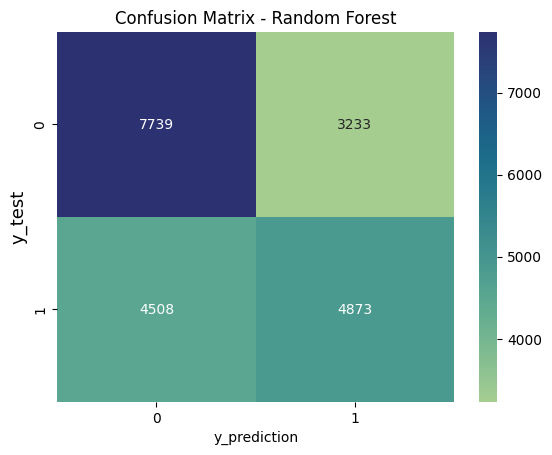

In [191]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="crest")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Logistic Regression AUC-ROC Score:0.66%


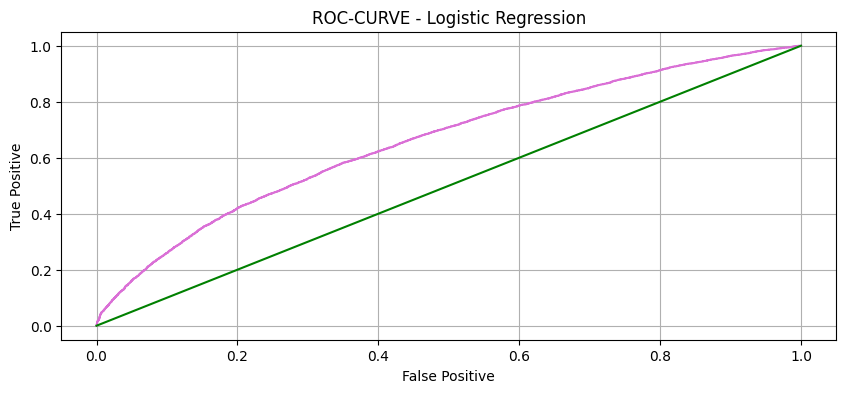

In [192]:
#AUC-ROC Curve - Logistic Regression (Fine-tuned)
#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"Logistic Regression AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="orchid", label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression")
plt.grid(True)
plt.show()

#### Random Forest

In [193]:
#Fine tuning Random Forest 

Model = RandomForestClassifier(random_state=42)

Model_pipeline = ImbPipeline([("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__n_estimators": [100, 200, 500],
    "Model__max_features": ["sqrt", "log2"],
    "Model__max_depth": [5, 10, 20],
    "Model__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

{'Model__criterion': 'entropy', 'Model__max_depth': 20, 'Model__max_features': 'sqrt', 'Model__n_estimators': 500}
0.6929986024547834


In [ ]:
#These are the best parameters: {'Model__criterion': 'entropy', 'Model__max_depth': 20, 'Model__max_features': 'sqrt', 'Model__n_estimators': 500}
best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

              precision    recall  f1-score   support

           0       0.66      0.68      0.67     10972
           1       0.61      0.59      0.60      9381

    accuracy                           0.64     20353
   macro avg       0.64      0.63      0.64     20353
weighted avg       0.64      0.64      0.64     20353



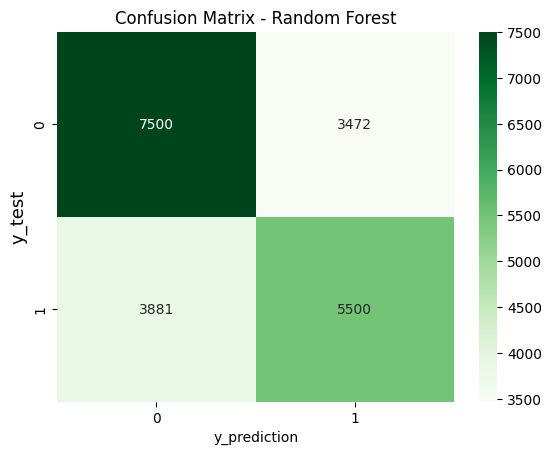

In [195]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Greens")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest")
plt.show()


Random Forest AUC-ROC Score:0.69%


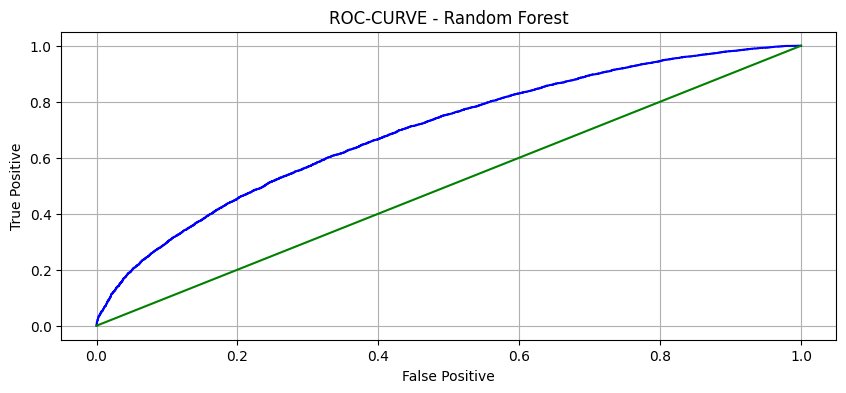

In [196]:
#AUC-ROC Curve - Random Forest (Fine-tuned)
tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"Random Forest AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest")
plt.grid(True)
plt.show()

#### XGBoost

In [ ]:
#Fine tuning XGBoost

Model = xgb.XGBClassifier(random_state=42)

Model_pipeline = ImbPipeline([("smote", SMOTE(random_state=42)), ("Model", Model)])

parameter_distribution = {
    "Model__n_estimators": [100, 200],
    "Model__max_depth": [3, 5, 6],
    "Model__learning_rate": [0.001, 0.01, 0.1],
    "Model__subsample": [0.5]
}

grid_search = GridSearchCV(estimator=Model_pipeline, param_grid=parameter_distribution, cv=5, n_jobs=1, scoring="roc_auc")

grid_search_result = grid_search.fit(X_train, y_train)
print(grid_search_result.best_params_)
print(grid_search_result.best_score_)

{'Model__learning_rate': 0.1, 'Model__max_depth': 5, 'Model__n_estimators': 200, 'Model__subsample': 0.5}
0.6982376358133406


In [ ]:
#These are the best parameters: {'Model__learning_rate': 0.1, 'Model__max_depth': 5, 'Model__n_estimators': 200, 'Model__subsample': 0.5}
best_params = grid_search.best_estimator_

tuned_y_prediction = best_params.predict(X_test)

tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

Classif_report = classification_report(y_test, tuned_y_prediction)
print(Classif_report)

              precision    recall  f1-score   support

           0       0.66      0.69      0.68     10972
           1       0.62      0.59      0.60      9381

    accuracy                           0.64     20353
   macro avg       0.64      0.64      0.64     20353
weighted avg       0.64      0.64      0.64     20353



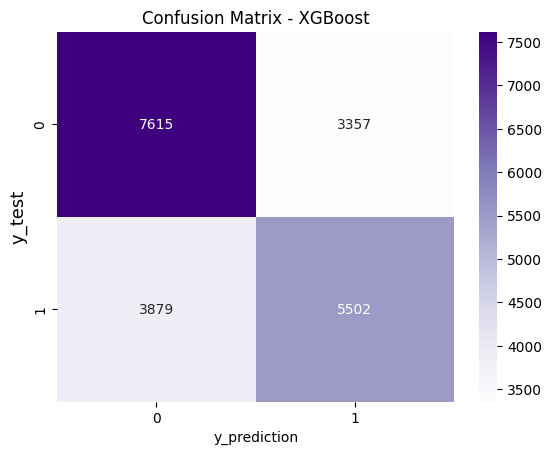

In [202]:
#For Confusion Matrix
confuse_matrix = confusion_matrix(y_test, tuned_y_prediction)
sns.heatmap(confuse_matrix, annot=True, fmt="g", cmap="Purples")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost")
plt.show()

XGBoost AUC-ROC Score:0.70%


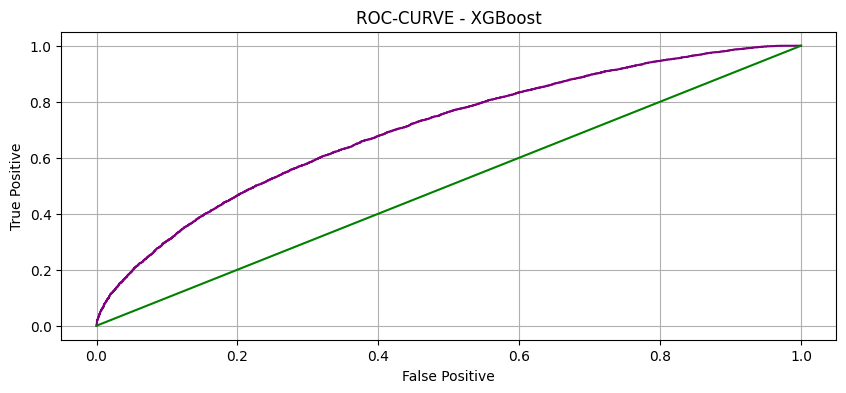

In [203]:
#AUC-ROC Curve - XGBoost (Fine-tuned)
tuned_y_probability = best_params.predict_proba(X_test)[:, 1]

#For AUC-ROC
auc_score = roc_auc_score(y_test, tuned_y_probability)
print(f"XGBoost AUC-ROC Score:{auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, tuned_y_probability)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color="purple", label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost")
plt.grid(True)
plt.show()